In [ ]:
!pip install -q streamlit streamlit-folium folium \
    rasterio geopandas scikit-learn scikit-image \
    plotly pyngrok qrcode[pil]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import shutil

REPO_URL = "https://github.com/HYDRO-CHRIS-LEE/flood-mapping-dashboard"
APP_DIR = "/content/app"
DRIVE_DATA_ROOT = "/content/drive/MyDrive/CHRS_EarthAI/data"

# Make sure we are not inside /content/app
%cd /content

# Kill old app if needed
!pkill -f streamlit || true

# Remove existing repo
if os.path.exists(APP_DIR):
    shutil.rmtree(APP_DIR)

# Clone from a safe directory
!cd /content && git clone {REPO_URL} app

# Prepare data folder
os.makedirs(f"{APP_DIR}/data", exist_ok=True)

EVENTS = [
    'harvey', 'pakistan', 'dubai', 'la2025',
    'afghanistan2024', 'brazil2024', 'china2020', 'iran2019',
    'libya2023', 'mozambique2019', 'somalia2023',
    'tennessee2021', 'valencia2024'
]

for event in EVENTS:
    src = f'{DRIVE_DATA_ROOT}/{event}'
    dst = f'{APP_DIR}/data/{event}'

    if not os.path.exists(src):
        print(f'[WARN] Missing source folder: {src}')
        continue

    if os.path.lexists(dst):
        if os.path.islink(dst) or os.path.isfile(dst):
            os.remove(dst)
        else:
            shutil.rmtree(dst)

    os.symlink(src, dst)

for event in EVENTS:
    d = f'{APP_DIR}/data/{event}'
    if not os.path.isdir(d):
        continue

    for f in os.listdir(d):
        prefix = f'{event}_'
        if f.startswith(prefix):
            old_path = os.path.join(d, f)
            new_path = os.path.join(d, f[len(prefix):])
            if not os.path.exists(new_path):
                os.rename(old_path, new_path)

    print(f'{event}: {sorted(os.listdir(d))}')

Mounted at /content/drive
/content
^C
Cloning into 'app'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 116 (delta 50), reused 107 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 861.01 KiB | 5.82 MiB/s, done.
Resolving deltas: 100% (50/50), done.
harvey: ['GPM_rainfall_daily.csv', 'SAR_after (1).tif', 'SAR_after.tif', 'SAR_before (1).tif', 'SAR_before.tif', 'NDWI_after (1).tif', 'NDWI_after.tif', 'RGB_before.tif', 'RGB_after.tif', 'NDWI_before.tif', 'JRC_permanent_water (1).tif', 'JRC_permanent_water.tif', 'RF_training_samples.csv', 'DEM_slope.tif']
pakistan: ['GPM_rainfall_daily.csv', 'SAR_before.tif', 'SAR_after.tif', 'NDWI_before.tif', 'NDWI_after.tif', 'RGB_before.tif', 'DEM_slope.tif', 'JRC_permanent_water.tif', 'RF_training_samples.csv', 'RGB_after.tif']
dubai: ['GPM_rainfall_daily.csv', 'SAR_before.tif', 'SAR_after.tif', 'NDWI_before.tif', 'NDWI_after

In [ ]:
import os
os.chdir('/content/app')

🌊 Public URL: https://isodimorphous-straddlingly-angelo.ngrok-free.dev
✅ QR code saved: /content/app/streamlit_qr.png


## 🌊 Student Access Link
### [https://isodimorphous-straddlingly-angelo.ngrok-free.dev](https://isodimorphous-straddlingly-angelo.ngrok-free.dev)

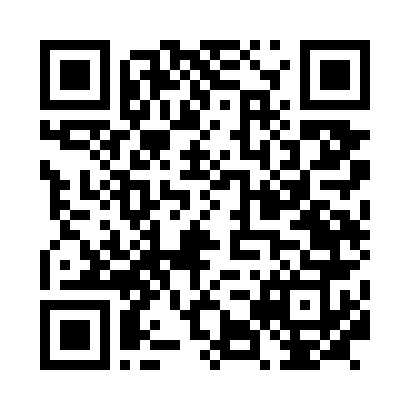


📱 Terminal QR code:
                                                                      
  ██████████████          ████    ████████  ██  ██    ██████████████  
  ██          ██    ██████  ██████  ██    ██          ██          ██  
  ██  ██████  ██  ██    ██  ██  ████  ████  ██    ██  ██  ██████  ██  
  ██  ██████  ██  ██  ██████  ██  ████        ████    ██  ██████  ██  
  ██  ██████  ██  ████  ██████  ██  ██████      ██    ██  ██████  ██  
  ██          ██  ████  ██      ████      ██████      ██          ██  
  ██████████████  ██  ██  ██  ██  ██  ██  ██  ██  ██  ██████████████  
                  ██████  ██  ████        ████████                    
  ██  ██████████    ██      ██████  ██    ██  ██  ██  ██████████      
  ██████    ██  ████  ██████      ██    ████    ██    ████  ████████  
      ██████  ████    ██████    ██        ██  ██  ████    ██  ████    
            ██  ██  ██  ██    ██████  ██  ██████    ██    ██████      
  ██          ██    ████  ██    ██  ██        ██  ████  

In [ ]:
from pyngrok import ngrok
import subprocess
import time
import os

# =========================
# Configuration
# =========================
APP_DIR = "/content/app"
APP_FILE = "app.py"
PORT = 8501
NGROK_TOKEN = "3B5ehADUXKq0ZZi4HTEtUi0VZvo_55qKBSCgjCeyprEUxLjHo"
QR_FILENAME = os.path.join(APP_DIR, "streamlit_qr.png")

# =========================
# 1) Authenticate ngrok
# =========================
ngrok.set_auth_token(NGROK_TOKEN)

# =========================
# 2) Launch Streamlit in background
# =========================
proc = subprocess.Popen(
    [
        "streamlit", "run", APP_FILE,
        "--server.port", str(PORT),
        "--server.headless", "true",
        "--browser.gatherUsageStats", "false"
    ],
    cwd=APP_DIR
)

# Wait a few seconds for Streamlit to start
time.sleep(5)

# =========================
# 3) Create public ngrok URL
# =========================
tunnel = ngrok.connect(PORT)
url = tunnel.public_url

print("=" * 60)
print(f"🌊 Public URL: {url}")
print("=" * 60)

# =========================
# 4) Generate QR code
# =========================
import qrcode

qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_M,
    box_size=10,
    border=4,
)
qr.add_data(url)
qr.make(fit=True)

img = qr.make_image(fill_color="black", back_color="white")
img.save(QR_FILENAME)

print(f"✅ QR code saved: {QR_FILENAME}")

# =========================
# 5) Display QR image in Colab / notebook
# =========================
try:
    from IPython.display import display, Image, Markdown
    display(Markdown(f"## 🌊 Student Access Link\n### [{url}]({url})"))
    display(Image(filename=QR_FILENAME))
except Exception as e:
    print(f"(Skipping notebook image display) {e}")

# =========================
# 6) Optional: print ASCII QR in terminal
# =========================
try:
    qr_terminal = qrcode.QRCode(border=1)
    qr_terminal.add_data(url)
    qr_terminal.make(fit=True)
    matrix = qr_terminal.get_matrix()

    print("\n📱 Terminal QR code:")
    for row in matrix:
        print("".join("██" if cell else "  " for cell in row))
except Exception as e:
    print(f"(Skipping ASCII QR output) {e}")

# =========================
# 7) Print student instructions
# =========================
print("\n" + "=" * 60)
print("Instructions for students")
print(f"1. Laptop users: open or type this link:\n   {url}")
print("2. Phone users: scan the QR code.")
print(f"3. QR image file: {QR_FILENAME}")
print("=" * 60)

In [ ]:
from pyngrok import ngrok
import subprocess, time, threading

ngrok.set_auth_token("3B5ehADUXKq0ZZi4HTEtUi0VZvo_55qKBSCgjCeyprEUxLjHo")

proc = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port", "8501",
     "--server.headless", "true"],
    cwd="/content/app"
)

time.sleep(5)

tunnel = ngrok.connect(8501)
url = tunnel.public_url
print("=" * 50)
print(f"🌊 공개 URL: {url}")
print(f"📱 이 URL로 QR 코드 만들어서 학생들에게 공유하세요")
print("=" * 50)

🌊 공개 URL: https://isodimorphous-straddlingly-angelo.ngrok-free.dev
📱 이 URL로 QR 코드 만들어서 학생들에게 공유하세요
